## 0. Import & Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. Define the Himmelblau Function

In [2]:
T_TEMP = 20.0            # Temperature for the distribution

# 1. Define the Himmelblau Function
def himmelblau(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2. Define the Log-Probability (Target Distribution)
# We use log-probability for numerical stability in MCMC later
def log_prob_himmelblau(x, T=1.0):
    # x is a numpy array of shape (..., 2)
    f_val = (x[..., 0]**2 + x[..., 1] - 11)**2 + (x[..., 0] + x[..., 1]**2 - 7)**2
    return -f_val / T

## 2. Visualize the Function

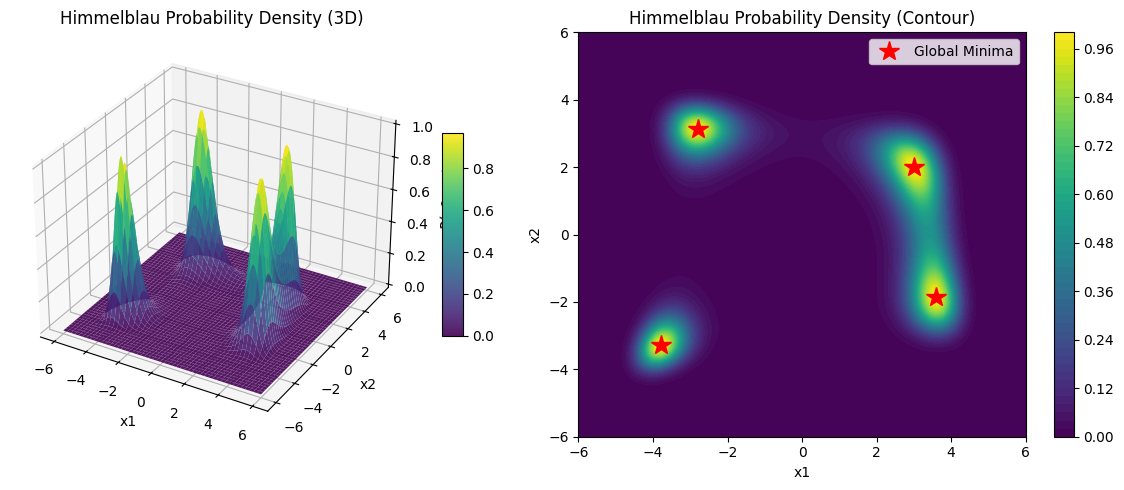

In [3]:
# 3. Create a Grid for Visualization
x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y)) # Shape: (400, 400, 2)

# Calculate Z values (Probability Density)
Z = np.exp(log_prob_himmelblau(pos, T=T_TEMP))

# 4. Plotting
fig = plt.figure(figsize=(12, 5))

# Plot 1: 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title('Himmelblau Probability Density (3D)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('P(x1, x2)')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: Contour Plot (Top-down view)
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis')
ax2.set_title('Himmelblau Probability Density (Contour)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
fig.colorbar(contour, ax=ax2)

# Mark the 4 known minima for reference
minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126]
])
ax2.plot(minima[:, 0], minima[:, 1], 'r*', markersize=15, label='Global Minima')
ax2.legend()

plt.tight_layout()
plt.savefig('../assets/himmelblau_density.png', dpi=300)
plt.show()

## 3. Classical MCMC Sampling (Metropolis-Hastings)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration ---
N_SAMPLES = 10000       # Total number of steps
BURN_IN = 1000          # Steps to discard at the start
PROPOSAL_STD = 1      # Standard deviation of the random walk proposal

In [5]:
# --- 2. Classical Random Walk Metropolis Function ---
def classical_mh(log_prob_fn, n_samples, initial_state, prop_std):
    """
    Runs Classical Random Walk Metropolis.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    current_state = np.array(initial_state, dtype=float)
    
    # Calculate initial log probability
    current_log_prob = log_prob_fn(current_state, T=T_TEMP)
    
    accepted_count = 0
    
    for i in range(n_samples):
        # 1. Propose: Add Gaussian noise
        # q(x* | x_t) = N(x_t, prop_std^2 * I)
        proposal = current_state + np.random.normal(0, prop_std, size=dim)
        
        # 2. Calculate Log Probability of Proposal
        proposal_log_prob = log_prob_fn(proposal, T=T_TEMP)
        
        # 3. Acceptance Ratio (Log Space)
        # Since proposal is symmetric, Hastings correction is 0
        log_alpha = proposal_log_prob - current_log_prob
        
        # 4. Accept/Reject
        if np.log(np.random.rand()) < log_alpha:
            current_state = proposal
            current_log_prob = proposal_log_prob
            accepted_count += 1
            
        # 5. Store Sample
        samples[i] = current_state
        
    acceptance_rate = accepted_count / n_samples
    return samples, acceptance_rate

In [6]:
# --- 3. Run Classical MH ---
print("Running Classical MCMC...")
initial_state = [0.0, 0.0] # Start at origin (low probability region)
samples_classical, acc_rate_classical = classical_mh(
    log_prob_himmelblau, 
    N_SAMPLES, 
    initial_state, 
    PROPOSAL_STD
)

print(f"Classical Acceptance Rate: {acc_rate_classical:.2f}")

Running Classical MCMC...
Classical Acceptance Rate: 0.41


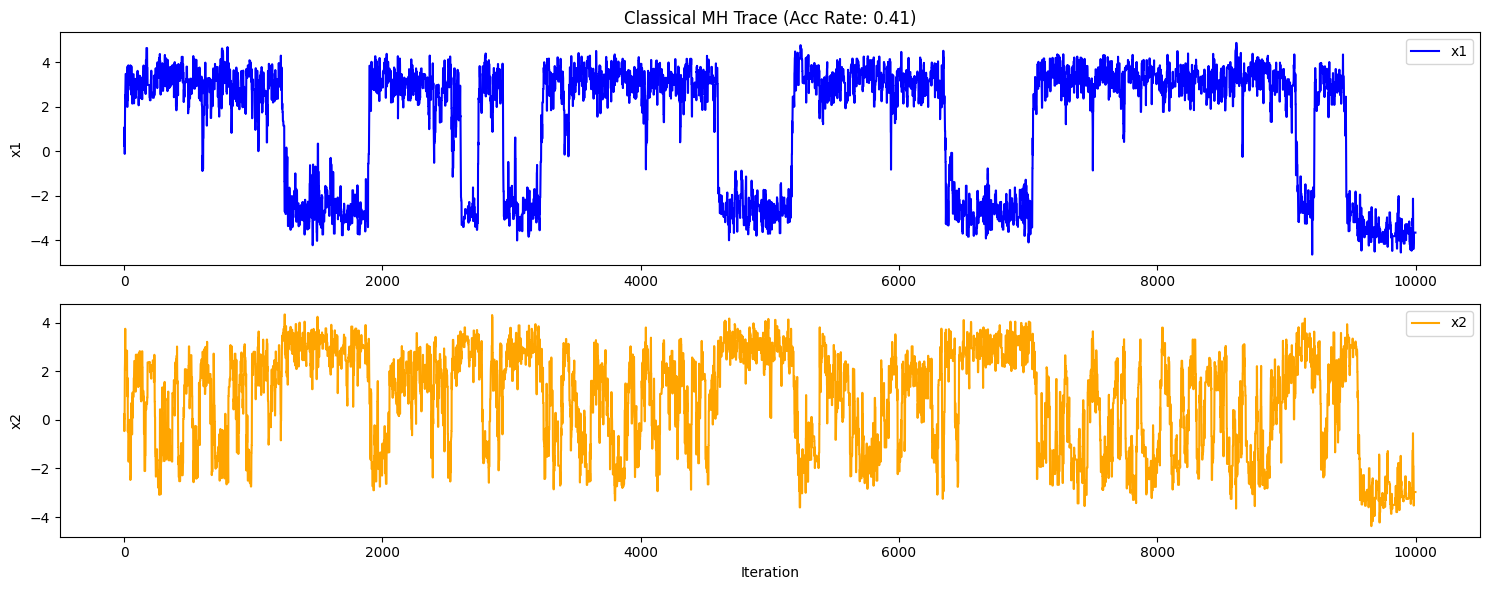

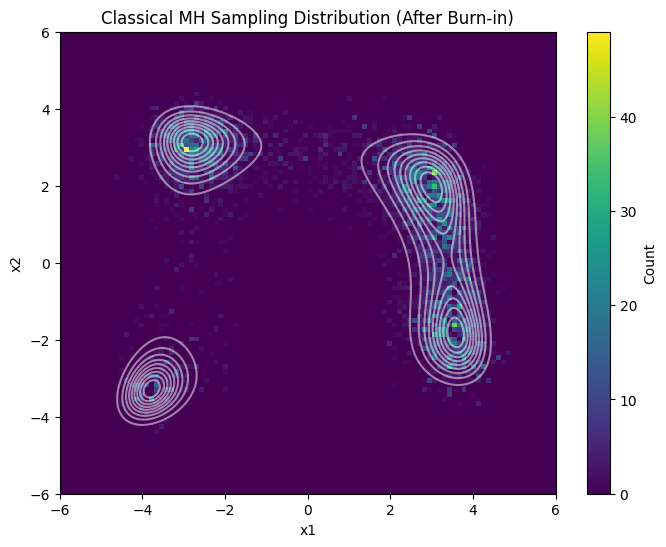

In [7]:
# --- 4. Visualization of Classical Results ---

# A. Trace Plot (How the values change over time)
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
axes[0].plot(samples_classical[:, 0], label='x1', color='blue')
axes[0].set_ylabel('x1')
axes[0].legend()
axes[0].set_title(f'Classical MH Trace (Acc Rate: {acc_rate_classical:.2f})')

axes[1].plot(samples_classical[:, 1], label='x2', color='orange')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration')
axes[1].legend()

plt.tight_layout()
plt.show()

# B. 2D Histogram (Where did the sampler go?)
plt.figure(figsize=(8, 6))
plt.hist2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
           bins=100, cmap='viridis', range=[[-6, 6], [-6, 6]])
plt.colorbar(label='Count')
plt.title('Classical MH Sampling Distribution (After Burn-in)')
plt.xlabel('x1')
plt.ylabel('x2')

# Overlay the true contours for reference
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))
plt.contour(X, Y, Z, levels=10, colors='white', alpha=0.5)

plt.show()

## 3. MH Sampling with Learned Proposals (NeuralMH)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# --- 1. Define the Proposal Network (MLP) ---
class ProposalNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=2):
        """
        input_dim: dimension of state (2 for Himmelblau)
        hidden_dim: neurons per hidden layer
        output_dim: dimension of output (same as input_dim)
        Output: [mu_x, mu_y, log_std_x, log_std_y]
        """
        super(ProposalNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),  # Tanh often works better than ReLU for symmetric landscapes
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2 * output_dim)  # mu and log_std for each dimension
        )
        
        # Initialize weights for stability
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        x: tensor of shape (batch, input_dim)
        returns: mu (batch, output_dim), log_std (batch, output_dim)
        """
        output = self.net(x)
        mu = output[:, :self.output_dim] if hasattr(self, 'output_dim') else output[:, :2]
        log_std = output[:, 2:] if hasattr(self, 'output_dim') else output[:, 2:]
        # Clamp log_std to prevent extreme values
        log_std = torch.clamp(log_std, -3, 2)  # std in [0.05, 7.4]
        return mu, log_std

# Set output_dim attribute for clarity
ProposalNet.output_dim = 2

In [9]:
# --- 2. Helper: Log Probability of Gaussian Proposal ---
def log_gaussian_proposal(x, mu, log_std):
    """
    Compute log q(x | mu, std) for diagonal Gaussian.
    x, mu: (batch, dim) or (dim,)
    log_std: (batch, dim) or (dim,)
    """
    # Ensure inputs are tensors
    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    if not torch.is_tensor(mu):
        mu = torch.tensor(mu, dtype=torch.float32)
    if not torch.is_tensor(log_std):
        log_std = torch.tensor(log_std, dtype=torch.float32)
    
    # Handle scalar vs batch
    if x.dim() == 1:
        x = x.unsqueeze(0)
        mu = mu.unsqueeze(0)
        log_std = log_std.unsqueeze(0)
    
    std = torch.exp(log_std)
    # Log PDF: -0.5*log(2π) - log_std - 0.5*((x-mu)/std)^2
    log_2pi = torch.log(torch.tensor(2 * np.pi))
    log_prob = -0.5 * log_2pi - log_std - 0.5 * ((x - mu) / std) ** 2
    return log_prob.sum(dim=1)  # Sum over dimensions

In [46]:
# --- 3. Neural MCMC Step with Hastings Correction ---
def neural_mh_step(current_state, log_prob_fn, model, optimizer, 
                   replay_buffer, batch_size=32, update_freq=50, 
                   entropy_beta=0.1, min_std=0.1, T=20.0):
    dim = len(current_state)
    current_tensor = torch.tensor(current_state, dtype=torch.float32).unsqueeze(0)
    
    # 1. Get proposal parameters from network
    with torch.no_grad():
        mu, log_std = model(current_tensor)
        mu_np = mu.numpy()[0]
        std_np = np.exp(log_std.numpy())[0]
        std_np = np.maximum(std_np, min_std)  # Enforce minimum std
    
    # 2. Propose new state
    proposal = current_state + np.random.normal(mu_np, std_np)
    
    # 3. Compute acceptance ratio (with Hastings correction)
    current_log_p = log_prob_fn(current_state, T=T)
    proposal_log_p = log_prob_fn(proposal, T=T)
    log_target_ratio = proposal_log_p - current_log_p
    
    # Hastings correction: log[q(current|proposal) / q(proposal|current)]
    with torch.no_grad():
        proposal_tensor = torch.tensor(proposal, dtype=torch.float32).unsqueeze(0)
        
        # Forward: q(proposal | current)
        mu_fwd, log_std_fwd = model(current_tensor)
        dist_fwd = torch.distributions.Normal(mu_fwd, torch.exp(log_std_fwd))
        log_q_fwd = dist_fwd.log_prob(proposal_tensor).sum(dim=1).item()
        
        # Backward: q(current | proposal)
        mu_bwd, log_std_bwd = model(proposal_tensor)
        dist_bwd = torch.distributions.Normal(mu_bwd, torch.exp(log_std_bwd))
        log_q_bwd = dist_bwd.log_prob(current_tensor).sum(dim=1).item()
    
    log_correction = log_q_bwd - log_q_fwd
    log_alpha = min(log_target_ratio + log_correction, 0.0)
    
    # 4. Accept/Reject
    accepted = np.log(np.random.rand()) < log_alpha
    next_state = proposal if accepted else current_state
    
    # 5. Store transition for training
    if accepted:
        replay_buffer.append((current_state.copy(), proposal.copy()))
    
    # 6. Training step (periodic)
    loss = None
    if len(replay_buffer) >= batch_size and np.random.rand() < 1/update_freq:
        batch_idx = np.random.choice(len(replay_buffer), batch_size, replace=False)
        batch = [replay_buffer[i] for i in batch_idx]
        inputs = torch.tensor([b[0] for b in batch], dtype=torch.float32)
        targets = torch.tensor([b[1] for b in batch], dtype=torch.float32)
        
        mu_pred, log_std_pred = model(inputs)
        std_pred = torch.exp(log_std_pred)
        
        dist = torch.distributions.Normal(mu_pred, std_pred)
        nll_loss = -dist.log_prob(targets).mean()
        entropy = dist.entropy().mean()
        
        loss = nll_loss - entropy_beta * entropy
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
    return proposal, next_state, accepted, loss

In [47]:
# --- 4. Run Neural MCMC ---
def run_neural_mcmc(log_prob_fn, n_samples, initial_state, 
                   warmup_steps=2000, prop_std_init=1.0,
                   hidden_dim=64, lr=1e-3, entropy_beta=0.1,
                   min_std=0.1, buffer_size=500, T=20.0):
    """
    Run the full Neural MCMC with warm-up and online training.
    """
    dim = len(initial_state)
    samples = np.zeros((n_samples, dim))
    proposals = np.zeros((n_samples, dim))  # For tracing proposals
    
    # Initialize model and optimizer
    model = ProposalNet(input_dim=dim, hidden_dim=hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Replay buffer for online training
    replay_buffer = deque(maxlen=buffer_size)
    
    current_state = np.array(initial_state, dtype=float)
    accepted_count = 0
    loss_history = []
    
    print("Starting Neural MCMC...")
    
    for i in range(n_samples):
        # Warm-up phase: use classical random walk
        if i < warmup_steps:
            proposal = current_state + np.random.normal(0, prop_std_init, size=dim)
            current_log_p = log_prob_fn(current_state, T=T)
            proposal_log_p = log_prob_fn(proposal, T=T)
            log_alpha = proposal_log_p - current_log_p
            
            if np.log(np.random.rand()) < log_alpha:
                current_state = proposal
                accepted_count += 1
        else:
            # Neural proposal phase
            proposal, current_state, accepted, loss = neural_mh_step(
                current_state, log_prob_fn, model, optimizer,
                replay_buffer, batch_size=32, update_freq=50,
                entropy_beta=entropy_beta, min_std=min_std, T=T
            )
            if accepted:
                accepted_count += 1
            if loss is not None:
                loss_history.append(loss.item())
        
        proposals[i] = proposal
        samples[i] = current_state
        
        # Progress update
        if (i+1) % 2000 == 0:
            acc_rate = accepted_count / (i+1)
            print(f"Step {i+1}/{n_samples}, Acc Rate: {acc_rate:.3f}")
            if loss_history:
                print(f"  Recent Loss: {loss_history[-1]:.4f}")
    
    overall_acc_rate = accepted_count / n_samples
    print(f"\nNeural MCMC Complete. Overall Acceptance Rate: {overall_acc_rate:.3f}")
    
    return samples, proposals, overall_acc_rate, model, loss_history

In [56]:
# --- 5. Execute Neural MCMC ---
print("="*50)
print("Running Neural MCMC on Himmelblau")
print("="*50)

# Same parameters as classical for fair comparison
N_SAMPLES = 10000
INITIAL_STATE = [0.0, 0.0]

# Fix seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

samples_neural, proposals_neural, acc_rate_neural, trained_model, loss_hist = run_neural_mcmc(
    log_prob_himmelblau,
    n_samples=N_SAMPLES,
    initial_state=INITIAL_STATE,
    warmup_steps=2000,      # First 20% classical to bootstrap
    prop_std_init=1.0,      # Same as classical
    hidden_dim=64,
    lr=1e-4,
    entropy_beta=0.0,       # Tunable: higher = more exploration
    min_std=0.1,            # Prevent collapse
    buffer_size=500,
    T=T_TEMP
)

Running Neural MCMC on Himmelblau
Starting Neural MCMC...
Step 2000/10000, Acc Rate: 0.400
Step 4000/10000, Acc Rate: 0.246
  Recent Loss: 2.9077
Step 6000/10000, Acc Rate: 0.183
  Recent Loss: 2.5492
Step 8000/10000, Acc Rate: 0.160
  Recent Loss: 2.2421
Step 10000/10000, Acc Rate: 0.129
  Recent Loss: 2.1053

Neural MCMC Complete. Overall Acceptance Rate: 0.129


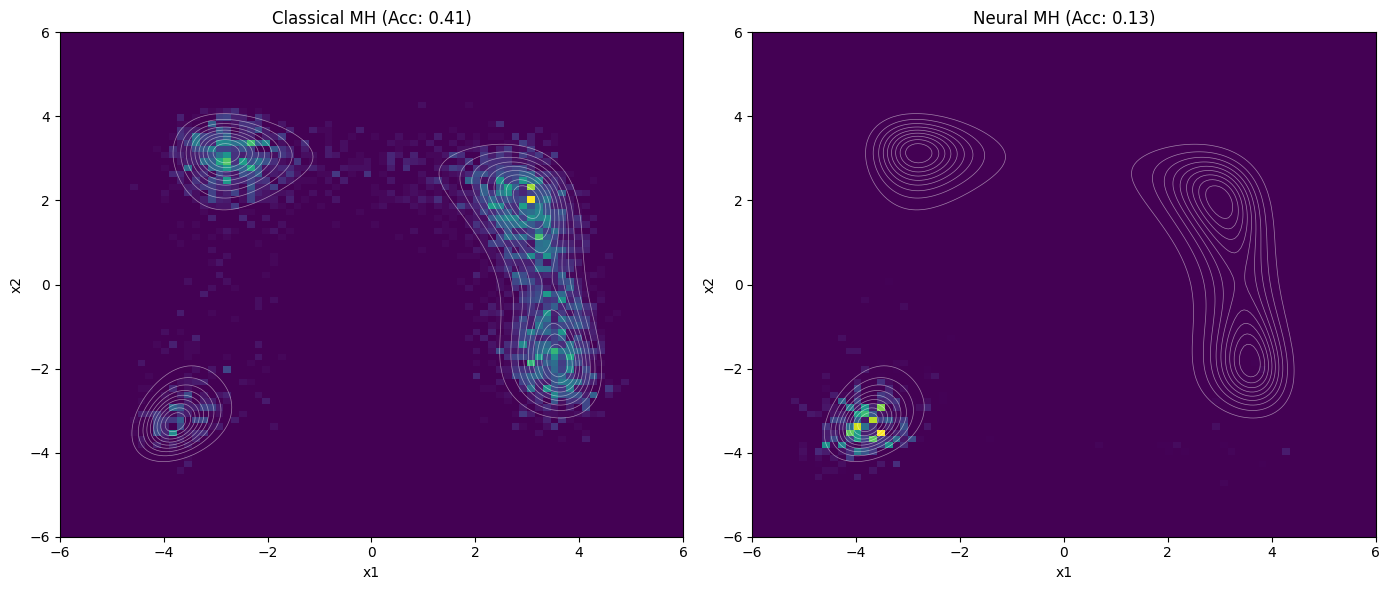

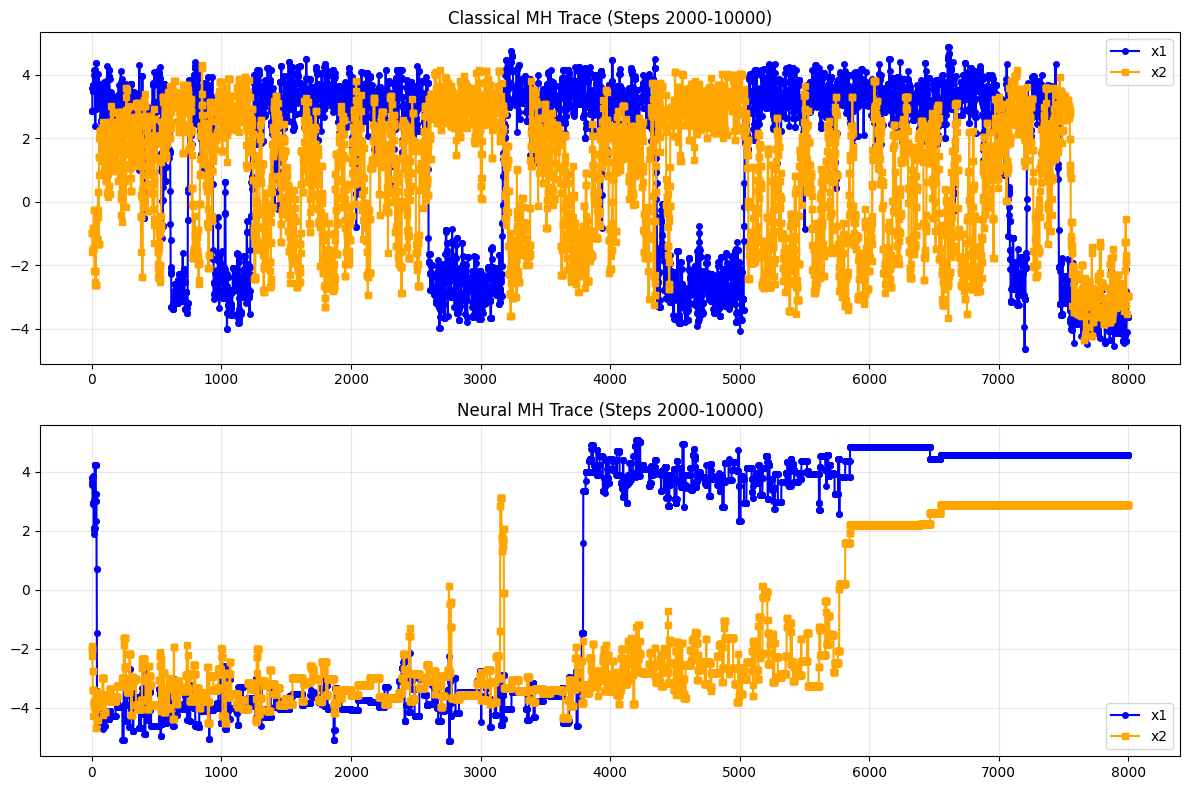

Mode Visitation Counts (Radius=1.0):
Classical: [1786. 1392.  350. 1603.]
Neural:    [3.000e+00 2.000e+00 3.378e+03 9.300e+02]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Compare 2D Histograms (Did we visit all modes?) ---
BURN_IN = 2000 # Discard warm-up

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Helper to plot contours
x_range = np.linspace(-6, 6, 200)
y_range = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = np.exp(log_prob_himmelblau(np.dstack((X, Y)), T=T_TEMP))

# Plot Classical
axes[0].hist2d(samples_classical[BURN_IN:, 0], samples_classical[BURN_IN:, 1], 
               bins=80, cmap='viridis', range=[[-6, 6], [-6, 6]])
axes[0].contour(X, Y, Z, levels=10, colors='white', alpha=0.5, linewidths=0.5)
axes[0].set_title(f'Classical MH (Acc: {acc_rate_classical:.2f})')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

# Plot Neural
axes[1].hist2d(samples_neural[BURN_IN:, 0], samples_neural[BURN_IN:, 1], 
               bins=80, cmap='viridis', range=[[-6, 6], [-6, 6]])
axes[1].contour(X, Y, Z, levels=10, colors='white', alpha=0.5, linewidths=0.5)
axes[1].set_title(f'Neural MH (Acc: {acc_rate_neural:.2f})')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')

plt.tight_layout()
plt.show()

# --- 2. Inspect Specific Jumps (Trace Zoom-in) ---
# Let's look at a window of 200 steps where the Neural sampler was active
start_idx = 2000 
window = 8000

plt.figure(figsize=(12, 8))

# Plot Classical Trace
plt.subplot(2, 1, 1)
plt.plot(samples_classical[start_idx:start_idx+window, 0], 'o-', label='x1', color='blue', markersize=4)
plt.plot(samples_classical[start_idx:start_idx+window, 1], 's-', label='x2', color='orange', markersize=4)
plt.title(f'Classical MH Trace (Steps {start_idx}-{start_idx+window})')
plt.legend(); plt.grid(alpha=0.3)

# Plot Neural Trace
plt.subplot(2, 1, 2)
plt.plot(samples_neural[start_idx:start_idx+window, 0], 'o-', label='x1', color='blue', markersize=4)
plt.plot(samples_neural[start_idx:start_idx+window, 1], 's-', label='x2', color='orange', markersize=4)
plt.title(f'Neural MH Trace (Steps {start_idx}-{start_idx+window})')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Mode Visitation Count ---
# Define regions for the 4 modes (approximate circles around minima)
minima = np.array([
    [3.0, 2.0],
    [-2.8, 3.1],
    [-3.8, -3.3],
    [3.6, -1.8]
])
radius = 1.0 # Distance threshold to count as "visiting" a mode

def count_mode_visits(samples, minima, radius):
    counts = np.zeros(len(minima))
    for s in samples:
        dists = np.sqrt(np.sum((s - minima)**2, axis=1))
        closest_mode = np.argmin(dists)
        if dists[closest_mode] < radius:
            counts[closest_mode] += 1
    return counts

counts_classical = count_mode_visits(samples_classical[BURN_IN:], minima, radius)
counts_neural = count_mode_visits(samples_neural[BURN_IN:], minima, radius)

print("Mode Visitation Counts (Radius=1.0):")
print(f"Classical: {counts_classical}")
print(f"Neural:    {counts_neural}")